Processed Part1
Processed Part2
Processed Part3
Processed Part4
Processed Part5
Processed Part6
Processed Part7
Processed Part8
Processed Part9
Processed Part10
Processed Part11
Processed Part12
Processed Part13
Processed Part14
Processed Part15
Processed Part16
Processed Part17
Processed Part18
Processed Part19
Processed Part20
Processed Part21
Processed Part22
Processed Part23
Processed Part24
Processed Part25
Processed Part26
Processed Part27
Processed Part28
Processed Part29
Processed Part30
Processed Part31
Processed Part32
Processed Part33
Processed Part34
Processed Part35
Processed Part36
Processed Part37
Processed Part38
Processed Part39
Processed Part40
Processed Part41
Processed Part42

Summary:
         HR_256Hz    HR_200Hz    HR_diff
count   42.000000   42.000000  42.000000
mean    81.166316   81.285120   0.134401
std      8.583202    8.494887   0.229680
min     68.385533   69.096947   0.000012
25%     74.553510   74.842831   0.012791
50%     79.739901   79.755164   0.02956

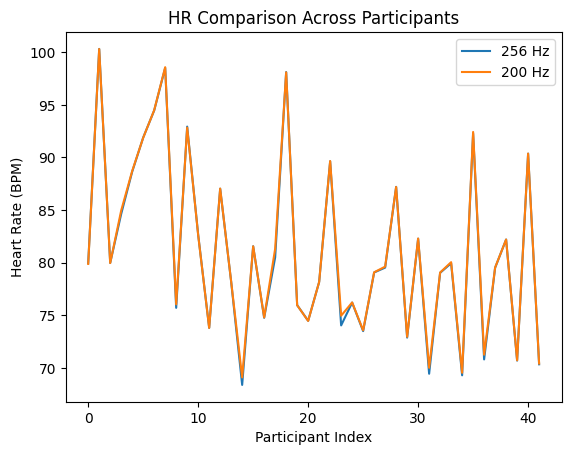

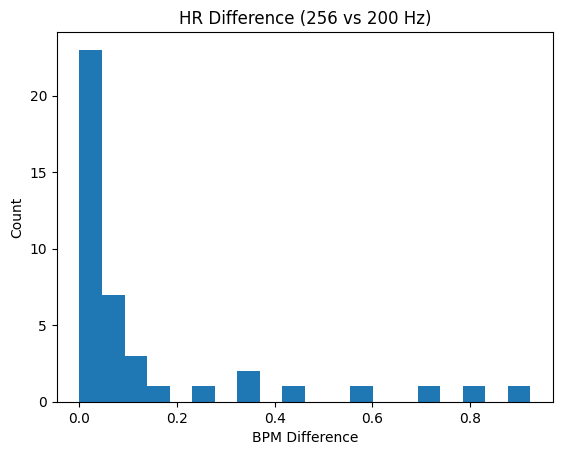


Pipeline complete.


In [4]:
# Full Pipeline Notebook: Resampling (256 Hz → 200 Hz) + HR Extraction
# ============================================================
# This notebook:
# 1. Loads all participants (Part1–Part42)
# 2. Cleans CLAS raw signals
# 3. Resamples 256 Hz → 200 Hz
# 4. Extracts HR from PPG
# 5. Compares HR before/after resampling
# 6. Saves processed data
# ============================================================

# ============================================================
# 1. Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import resample_poly, find_peaks

# ============================================================
# 2. Paths
# ============================================================
base_path = Path("../data/raw/Participants")
output_path = Path("../data/processed/200Hz")
output_path.mkdir(parents=True, exist_ok=True)

participants = [f"Part{i}" for i in range(1, 43)]

# ============================================================
# 3. Parameters
# ============================================================
fs_old = 256
fs_new = 200
up = 25
Down = 32

# ============================================================
# 4. Helper Functions
# ============================================================

def clean_signal(df):
    return df.dropna(subset=['ppg', 'gsr']).reset_index(drop=True)


def resample_signal(signal):
    return resample_poly(signal, up, Down)


def compute_hr(ppg_signal, fs):
    # Simple peak detection for HR
    peaks, _ = find_peaks(ppg_signal, distance=fs*0.5)  # min 0.5s between beats
    if len(peaks) < 2:
        return np.nan
    ibi = np.diff(peaks) / fs
    hr = 60 / np.mean(ibi)
    return hr

# ============================================================
# 5. Main Loop
# ============================================================
results = []

for part in participants:
    try:
        file_path = base_path / part / "full_gsr_ppg.csv"
        df = pd.read_csv(file_path)

        # Clean data
        df_clean = clean_signal(df)

        if len(df_clean) < 1000:
            continue

        ppg = df_clean['ppg'].values
        gsr = df_clean['gsr'].values

        # Resample
        ppg_resampled = resample_signal(ppg)
        gsr_resampled = resample_signal(gsr)

        # HR calculation
        hr_old = compute_hr(ppg, fs_old)
        hr_new = compute_hr(ppg_resampled, fs_new)

        results.append({
            "participant": part,
            "HR_256Hz": hr_old,
            "HR_200Hz": hr_new,
            "HR_diff": abs(hr_old - hr_new)
        })

        # Save resampled signals
        out_df = pd.DataFrame({
            "ppg_200Hz": ppg_resampled,
            "gsr_200Hz": gsr_resampled
        })

        out_file = output_path / f"{part}_200Hz.csv"
        out_df.to_csv(out_file, index=False)

        print(f"Processed {part}")

    except Exception as e:
        print(f"Skipping {part}: {e}")

# ============================================================
# 6. Results Analysis
# ============================================================
results_df = pd.DataFrame(results)

print("\nSummary:")
print(results_df.describe())

# ============================================================
# 7. Plot HR Comparison
# ============================================================
plt.figure()
plt.plot(results_df['HR_256Hz'], label="256 Hz")
plt.plot(results_df['HR_200Hz'], label="200 Hz")
plt.legend()
plt.title("HR Comparison Across Participants")
plt.xlabel("Participant Index")
plt.ylabel("Heart Rate (BPM)")
plt.show()

# ============================================================
# 8. HR Difference Plot
# ============================================================
plt.figure()
plt.hist(results_df['HR_diff'].dropna(), bins=20)
plt.title("HR Difference (256 vs 200 Hz)")
plt.xlabel("BPM Difference")
plt.ylabel("Count")
plt.show()

# ============================================================
# 9. Save Results
# ============================================================
results_df.to_csv(output_path / "HR_comparison.csv", index=False)

print("\nPipeline complete.")

